In [1]:
import json
import os
try:
    from backend.utils import load_json
except ModuleNotFoundError:
    print("Updating working directory....")
    os.chdir("../")
    print(os.getcwd())
    from backend.utils import load_json
    
from tqdm import tqdm 
from backend.utils import load_response_dict
from backend.dataset_utils import organize_dataset
from backend.nli_labels import ExNLILabel
import math

import matplotlib.pyplot as plt
import numpy as np

from backend.uncertainty.utils import remove_invalid, calculate_probs, find_relevant_logprobs, sort_correct_wrong
from backend.uncertainty.metrics import calculate_uncertainty
import itertools

Updating working directory....
/home/baratovfs/repos/contractnli-llms


In [2]:
# load dataset
dataset = load_json("data/test.json")
dataset = organize_dataset(dataset)

response_dirs = {
    "Qwen3 30B": [[
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed42"
    ], "classification"],
    "Gemma3 27B": [[
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed42"
    ], "classification"],
    "GPT-OSS 20B": [[
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed42"
    ], None],
    "LLaMA3.1 8B": [[
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed42"
    ], "classification"]
}

    # load and process responses

model_responses = {}
for model, (response_dir, structure) in response_dirs.items():
    correct, wrong = {}, {}
    for fp in response_dir:
        try:
            responses = load_response_dict(fp)
        except FileNotFoundError:
            continue
        remove_invalid(responses)

        # add probabilities to responses
        calculate_probs(responses, structure=structure)
        find_relevant_logprobs(responses, return_all=True)
        calculate_uncertainty(responses)

        # find correct/wrong
        c, w = sort_correct_wrong(dataset, responses)

        # complicated indexing to save on boilerplating 
        for big_dict, sub_dict in [(correct, c), (wrong, w)]:
            if len(big_dict) == 0:
                for k,v in sub_dict.items():
                    big_dict[k] = v
            else:
                for k,v in big_dict.items():
                    big_dict[k] = v + sub_dict[k]
    
    model_responses[model] = {
        "correct": correct,
        "wrong": wrong
    }

Loading responses:   0%|          | 0/123 [00:00<?, ?it/s]

Loading responses: 100%|██████████| 123/123 [00:48<00:00,  2.53it/s]


Removed 3 invalid answers!


Probabilities:  17%|█▋        | 21/123 [00:03<00:14,  7.26it/s]/home/baratovfs/repos/contractnli-llms/backend/uncertainty/metrics.py:14: RuntimeWarning: overflow encountered in exp
  return np.exp(average_logprob(logprobs))
Sorting: 100%|██████████| 123/123 [00:00<00:00, 40361.40it/s]


Num correct: 1536
Num wrong:   552


...

Num correct: 1021
Num wrong:   1070


Loading responses: 100%|██████████| 123/123 [00:00<00:00, 152.17it/s]


Removed 0 invalid answers!


Sorting: 100%|██████████| 123/123 [00:00<00:00, 55688.62it/s]

Num correct: 959
Num wrong:   1132


In [12]:
sorted_results_per_model = {}

for model, v in model_responses.items():
    sorted_results_per_model[model] = {}
    for k in ["correct", "wrong"]:
        print([len(vv) for vv in v[k].values()])
        all_responses = list(itertools.chain.from_iterable(v[k].values()))
        metrics_only = [ar["uncertainty"]["entropy"] for ar in all_responses]
        sorted_results_per_model[model][k] = metrics_only
        print(len(sorted_results_per_model[model][k]))

[1831, 2294, 509]
4634
[556, 480, 592]
1628
[1560, 2771, 392]
4723
[1166, 202, 182]
1550
[1909, 2406, 477]
4792
[625, 516, 340]
1481
[446, 2455, 152]
3053
[2423, 548, 249]
3220


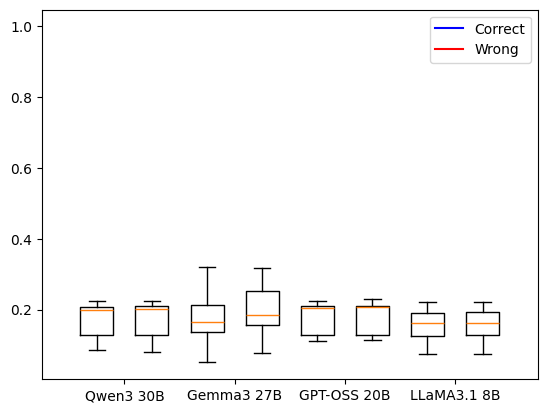

In [17]:

from pylab import plot, show, savefig, xlim, figure, \
                ylim, legend, boxplot, setp, axes


# function for setting the colors of the box plots pairs
def setBoxColors(bp):
    setp(bp['boxes'][0], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['fliers'][0], color='blue')
    setp(bp['fliers'][1], color='blue')
    setp(bp['medians'][0], color='blue')

    setp(bp['boxes'][1], color='red')
    setp(bp['caps'][2], color='red')
    setp(bp['caps'][3], color='red')
    setp(bp['whiskers'][2], color='red')
    setp(bp['whiskers'][3], color='red')
    setp(bp['fliers'][2], color='red')
    setp(bp['fliers'][3], color='red')
    setp(bp['medians'][1], color='red')

def boxplot_multiple_models(sorted_results_per_model: dict, save_file, title=None, xlabel=None, ylabel=None):
    if title is None:
        title = "Uncertainty per model"
    if xlabel is None:
        title = "Model"
    if ylabel is None:
        ylabel = "Uncertainty"
    
    fig = figure()
    ax = axes()
    for i, (model, sorted_results) in enumerate(sorted_results_per_model.items()):
        results = [sorted_results["correct"], sorted_results["wrong"]]
        

        # first boxplot pair
        k = i+1
        bp = boxplot(results, positions = [k*2, k*2+1], widths = 0.6)
        

    # set axes limits and labels
    xlim(1,10)
    ax.set_xticks([2.5 + 2 * (i+0) for i in range(len(sorted_results_per_model.keys()))])
    ax.set_xticklabels(sorted_results_per_model.keys())

    # draw temporary red and blue lines and use them to create a legend
    hB, = plot([1,1],'b-')
    hR, = plot([1,1],'r-')
    legend((hB, hR),('Correct', 'Wrong'))
    hB.set_visible(False)
    hR.set_visible(False)

    savefig(save_file)
    show()

boxplot_multiple_models(sorted_results_per_model, save_file="demo.png")